# Setup

In [1]:
from torch_harmonics.polar_harmonics import PolarHarmonics

In [2]:
K = 5
L = 3
ph = PolarHarmonics(K, L)
ph.Psi.shape

torch.Size([1, 35, 100, 360])

# Plotting the Polar Harmonics

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from torch_harmonics import plotting

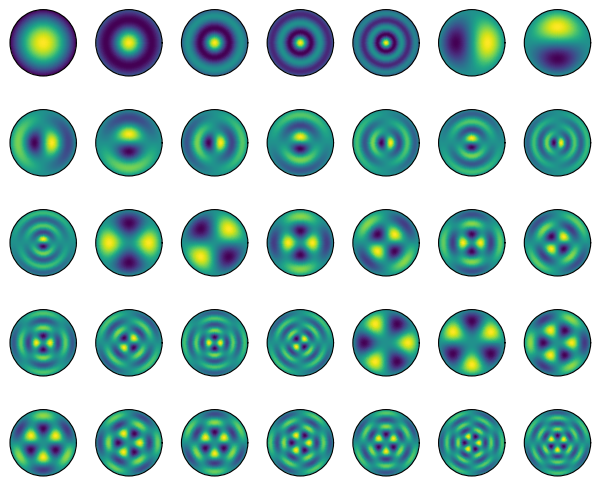

In [4]:
basis_fns = ph.Psi.view(K, L*2+1, ph.num_radii, ph.num_phi)

fig = plt.figure(figsize=(2*L, K))
subfigs = fig.subfigures(K, L*2+1)
for k in range(K):
    for l in range(L*2+1):
            plotting.plot_polar_fn(basis_fns[k,l].numpy(), fig=subfigs[k, l])

# Polar Harmonics Transform

In [5]:
import torch
from torch import nn

In [6]:
r = torch.linspace(0,1,100)
phi = torch.linspace(0,2*np.pi,360)
y = (1-r).view(100,1) @ (np.cos(phi) + np.sin(phi)).view(1,360)

<PolarAxes: >

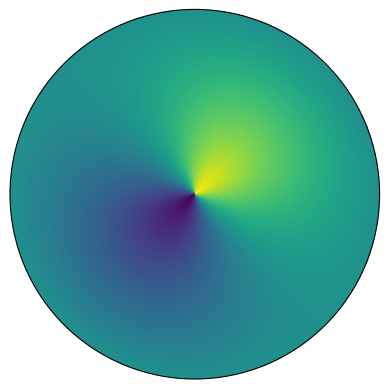

In [7]:
plotting.plot_polar_fn(y.numpy())

In [8]:
class PHT(nn.Module):
    def __init__(self, K=1, L=3, num_radii=100, num_phi=360):
        super().__init__()
        self.w_lin = nn.Linear(num_radii * num_phi, K*(L*2+1))
        self.ph = PolarHarmonics(K,L)

    def forward(self, x):
        w = self.w_lin(x)
        return self.ph(w), w.detach()

In [9]:
K = 5
L = 3
ph_model = PHT(K,L)
optimizer = torch.optim.Adam(ph_model.parameters(), lr = 1e-4)

for iter in range(200):
    y_pred, _ = ph_model(y.view(1,-1))
    loss = (y_pred - y).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 10 == 0:
        print(f'iteration: {iter} loss: {loss.item()}')

iteration: 0 loss: 1.1756117343902588
iteration: 10 loss: 9.322343826293945
iteration: 20 loss: 3.5876624584198
iteration: 30 loss: 0.7824559211730957
iteration: 40 loss: 0.21008910238742828
iteration: 50 loss: 0.09294978529214859
iteration: 60 loss: 0.06578502804040909
iteration: 70 loss: 0.05451154708862305
iteration: 80 loss: 0.043349746614694595
iteration: 90 loss: 0.03762310370802879
iteration: 100 loss: 0.03759034723043442
iteration: 110 loss: 0.03673778101801872
iteration: 120 loss: 0.036785539239645004
iteration: 130 loss: 0.036662567406892776
iteration: 140 loss: 0.03665638342499733
iteration: 150 loss: 0.03665084019303322
iteration: 160 loss: 0.03664681687951088
iteration: 170 loss: 0.03664605692028999
iteration: 180 loss: 0.03664594516158104
iteration: 190 loss: 0.036645885556936264


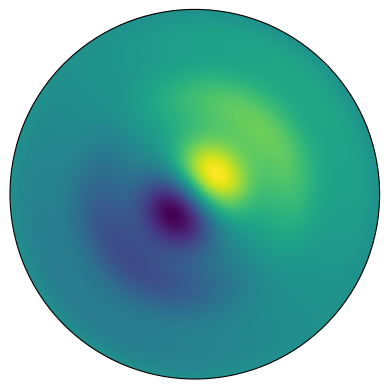

In [10]:
with torch.no_grad():
    pred, w = ph_model(y.view(1,-1))
    plotting.plot_polar_fn(pred.squeeze().numpy())

In [11]:
w_ph = torch.einsum("bwrp,bw->bwrp", ph_model.ph.Psi, w).view(K,2*L+1, ph_model.ph.num_radii, ph_model.ph.num_phi)
w.numpy().round(2)

array([[ 0.  ,  0.  ,  0.  , -0.  ,  0.  ,  0.66,  0.65,  0.24,  0.24,
         0.15,  0.15,  0.1 ,  0.1 ,  0.14,  0.14, -0.  , -0.  , -0.  ,
        -0.  , -0.  , -0.  , -0.  , -0.  , -0.  , -0.  , -0.  , -0.  ,
        -0.  , -0.  , -0.  , -0.  , -0.  , -0.  , -0.  , -0.  ]],
      dtype=float32)

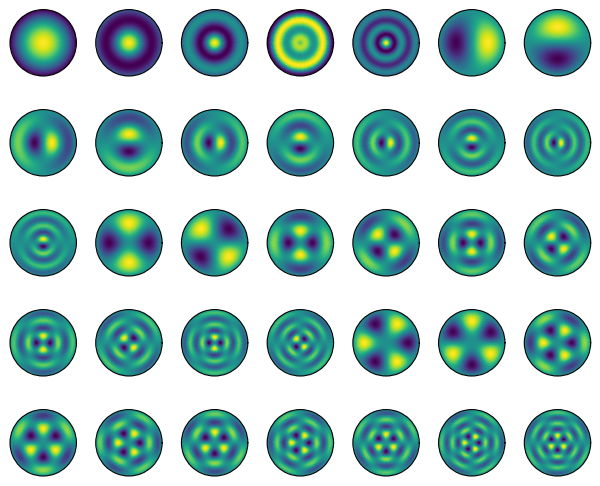

In [12]:
fig = plt.figure(figsize=(2*L, K))
subfigs = fig.subfigures(K, L*2+1)
for k in range(K):
    for l in range(L*2+1):
            plotting.plot_polar_fn(w_ph[k,l].numpy(), fig=subfigs[k, l])

In [ ]:
basis_fns = ph_model.ph.Psi.view(K, L*2+1, ph.num_radii, ph.num_phi)

fig = plt.figure(figsize=(2*L, K))
subfigs = fig.subfigures(K, L*2+1)
for k in range(K):
    for l in range(L*2+1):
            plotting.plot_polar_fn(basis_fns[k,l].numpy(), fig=subfigs[k, l])